In [ ]:
# !pip install pyts

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from pyts.image import RecurrencePlot
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
# Set random seeds for research reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using compute device: {device}")

[INFO] Using compute device: cpu


In [ ]:

# ==============================================================================
# STEP 1: DIRECT DATA LOADING AND PREPROCESSING (WITH BALANCED WINDOW SAMPLING)
# ==============================================================================
def load_and_preprocess_single_csv(file_path, window_size=64, max_samples=4000):
    """
    Loads a CAN intrusion CSV file, factorizes CAN IDs, and creates balanced
    sliding-window sequences (50% Normal, 50% Attack).
    """
    print(f"[INFO] Reading CSV directly from path: {file_path}")

    # Standard Kaggle/HCRL CAN Intrusion Dataset Columns
    df = pd.read_csv(
        file_path,
        names=['Timestamp', 'CAN_ID', 'DLC', 'D0', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'Flag'],
        on_bad_lines='skip',
        low_memory=False
    )

    # Clean string format and factorize CAN IDs to categorical indices
    df['CAN_ID'] = df['CAN_ID'].astype(str).str.strip()
    df['CAN_ID_Categorical'] = pd.factorize(df['CAN_ID'])[0]

    # Map Flag: 'R' = Normal (0), 'T' or anything else = Attack (1)
    df['Label'] = df['Flag'].apply(lambda x: 0 if str(x).strip().upper() == 'R' else 1)

    can_ids = df['CAN_ID_Categorical'].values
    lbl_vals = df['Label'].values

    # -------------------------------------------------------------------------
    # REPLACE OLD LOOP WITH THIS BALANCED SAMPLING LOGIC
    # -------------------------------------------------------------------------
    normal_seqs, attack_seqs = [], []

    # Extract non-overlapping sliding windows
    for i in range(0, len(can_ids) - window_size, window_size):
        win_seq = can_ids[i : i + window_size]
        win_lbl = 1 if np.any(lbl_vals[i : i + window_size] == 1) else 0

        if win_lbl == 1:
            attack_seqs.append(win_seq)
        else:
            normal_seqs.append(win_seq)

    # Balance classes equally (50% Normal, 50% Attack)
    min_samples = min(len(normal_seqs), len(attack_seqs), max_samples // 2)

    normal_seqs = normal_seqs[:min_samples]
    attack_seqs = attack_seqs[:min_samples]

    X_raw = np.array(normal_seqs + attack_seqs)
    y_raw = np.array([0] * min_samples + [1] * min_samples)

    # Shuffle maintaining alignment
    indices = np.arange(len(X_raw))
    np.random.shuffle(indices)
    X_raw = X_raw[indices]
    y_raw = y_raw[indices]
    # -------------------------------------------------------------------------

    print(f"[INFO] Successfully loaded {len(X_raw)} balanced sequences.")
    print(f"[INFO] Class breakdown -> Normal (0): {np.sum(y_raw == 0)}, Attack (1): {np.sum(y_raw == 1)}")

    return X_raw, y_raw

# Pass your exact Google Drive path here
dataset_path = "/content/drive/MyDrive/CAN/DoS_dataset.csv"


# Pass max_samples=10000 (or higher) to extract more windows
X_raw, y_raw = load_and_preprocess_single_csv(
    file_path=dataset_path,
    window_size=128,
    max_samples=20000
)

[INFO] Reading CSV directly from path: /content/drive/MyDrive/CAN/DoS_dataset.csv
[INFO] Successfully loaded 312 balanced sequences.
[INFO] Class breakdown -> Normal (0): 156, Attack (1): 156


In [ ]:
# ==============================================================================
# STEP 2: NATIVE CATEGORICAL RECURRENCE PLOT GENERATION
# ==============================================================================
print("[INFO] Generating Native Categorical Recurrence Plots...")

def generate_categorical_rp(X_sequences):
    """
    Transforms 1D categorical CAN ID sequences into 2D Recurrence Plots
    by evaluating exact frame equality (1 if ID_i == ID_j, else 0).
    """
    N, W = X_sequences.shape
    # Broadcast subtraction to find identical CAN IDs across time steps
    # Shape: (N, W, W)
    rp_matrices = (X_sequences[:, :, None] == X_sequences[:, None, :]).astype(np.float32)
    return rp_matrices

# Generate 2D binary recurrence matrices
X_rp = generate_categorical_rp(X_raw)

# Reshape to (N, Channels=1, Height=W, Width=W) for PyTorch 2D Conv Layers
X_rp = np.expand_dims(X_rp, axis=1)

# Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_rp, y_raw, test_size=0.20, random_state=SEED, stratify=y_raw
)

[INFO] Generating Native Categorical Recurrence Plots...


In [ ]:
# PyTorch Dataset Wrapper
class CANDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

train_loader = DataLoader(CANDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(CANDataset(X_test, y_test), batch_size=32, shuffle=False)

In [ ]:
# ==============================================================================
# STEP 3: LIGHTWEIGHT CNN ARCHITECTURE
#


class LightweightCANCNN(nn.Module):
    def __init__(self, window_size=128):
        super(LightweightCANCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # Shape: (16, W//2, W//2) -> (16, 64, 64)

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # Shape: (32, W//4, W//4) -> (32, 32, 32)
        )

        # 32 channels * 32 * 32 = 32,768 features
        flattened_size = 32 * (window_size // 4) * (window_size // 4)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.classifier(self.features(x))
model = LightweightCANCNN(window_size=128).to(device)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)


criterion = nn.CrossEntropyLoss(label_smoothing=0.15)

optimizer = optim.Adam(model.parameters(), lr=0.0003, weight_decay=5e-3)



In [ ]:
# Simple Early Stopping logic
best_loss = float('inf')
patience = 2
patience_counter = 0
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_loss = running_loss / len(train_loader)
    train_acc = (correct_train / total_train) * 100

    print(f"  Epoch [{epoch+1:02d}/{epochs:02d}] - Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}%")

    # Early stopping check
    if avg_loss < best_loss:
        best_loss = avg_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"[INFO] Early stopping triggered at Epoch {epoch+1} to avoid overfitting.")
            break

  Epoch [01/05] - Loss: 0.2974 | Train Acc: 100.00%
  Epoch [02/05] - Loss: 0.2856 | Train Acc: 100.00%
  Epoch [03/05] - Loss: 0.2886 | Train Acc: 100.00%
  Epoch [04/05] - Loss: 0.2852 | Train Acc: 100.00%
  Epoch [05/05] - Loss: 0.2895 | Train Acc: 100.00%


In [ ]:
# ==============================================================================
# STEP 5: PERFORMANCE EVALUATION & TEST ACCURACY
# ==============================================================================
print("\n[INFO] Evaluating model on unseen test set...")
model.eval()
y_pred, y_true = [], []
correct_test = 0
total_test = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        # Track test accuracy
        total_test += labels.size(0)
        correct_test += (preds == labels).sum().item()

        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

# Calculate Final Accuracies & Metrics
train_accuracy_final = train_acc  # Final epoch train accuracy
test_accuracy_final = (correct_test / total_test) * 100

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
cm = confusion_matrix(y_true, y_pred)

print("\n" + "="*50)
print("        CAN INTRUSION DETECTION PERFORMANCE REPORT")
print("="*50)
print(f" Training Accuracy : {train_accuracy_final:.2f}%")
print(f" Testing Accuracy  : {test_accuracy_final:.2f}%")
print(f" Precision         : {precision:.4f}")
print(f" Recall            : {recall:.4f}")
print(f" F1-Score          : {f1:.4f}")
print("="*50)
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal (0)', 'Attack (1)']))


[INFO] Evaluating model on unseen test set...

        CAN INTRUSION DETECTION PERFORMANCE REPORT
 Training Accuracy : 100.00%
 Testing Accuracy  : 95.24%
 Precision         : 0.9375
 Recall            : 0.9677
 F1-Score          : 0.9524

Detailed Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.97      0.94      0.95        32
  Attack (1)       0.94      0.97      0.95        31

    accuracy                           0.95        63
   macro avg       0.95      0.95      0.95        63
weighted avg       0.95      0.95      0.95        63



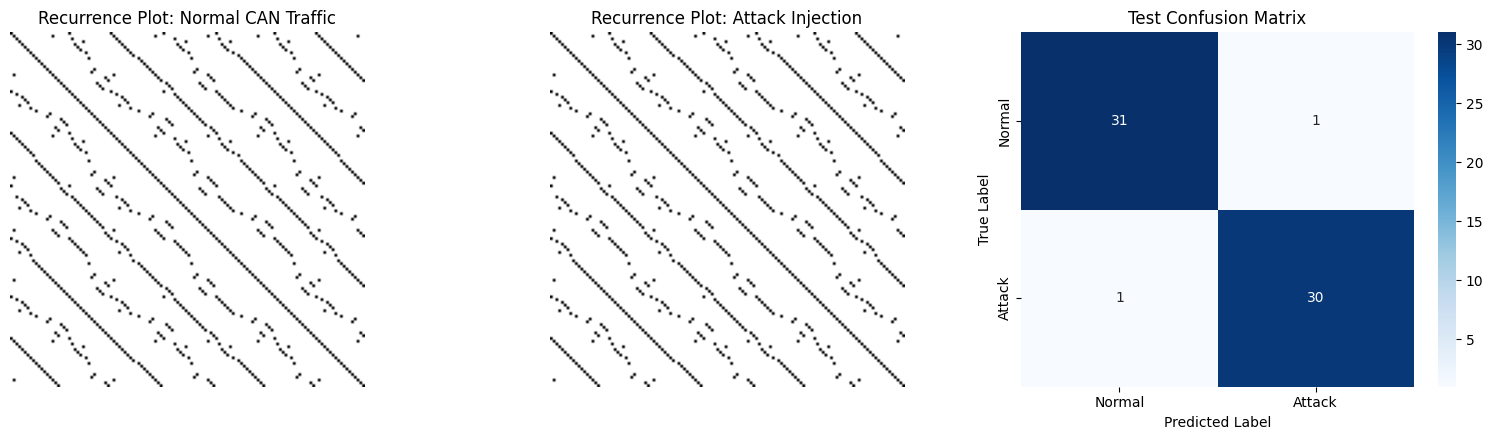

In [ ]:
# ==============================================================================
# STEP 6: VISUALIZATION (Recurrence Plots + Confusion Matrix)
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Plot 1: Recurrence Plot - Normal Frame
axes[0].imshow(X_rp[0, 0], cmap='binary')
axes[0].set_title("Recurrence Plot: Normal CAN Traffic")
axes[0].axis('off')

# Plot 2: Recurrence Plot - Attack Frame
attack_idx = np.where(y_raw == 1)[0][0] if 1 in y_raw else 1
axes[1].imshow(X_rp[attack_idx, 0], cmap='binary')
axes[1].set_title("Recurrence Plot: Attack Injection")
axes[1].axis('off')

# Plot 3: Confusion Matrix
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack']
)
axes[2].set_title("Test Confusion Matrix")
axes[2].set_xlabel("Predicted Label")
axes[2].set_ylabel("True Label")

plt.tight_layout()
plt.show()

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
from pyts.image import RecurrencePlot

# ==============================================================================
# STEP 1: SAVE MODEL WEIGHTS & CONFIG (Kaggle Output Directory)
# ==============================================================================
# Using Kaggle's working directory instead of Google Drive
MODEL_SAVE_PATH = "/content/drive/MyDrive/CAN/lightweight_can_cnn.pth"

# Save state dictionary with window_size=128 matching model structure
torch.save({
    'model_state_dict': model.state_dict(),
    'window_size': 128
}, MODEL_SAVE_PATH)

print(f"[INFO] Model checkpoint successfully saved to '{MODEL_SAVE_PATH}'")


# ==============================================================================
# STEP 2: LOAD MODEL FOR INFERENCE
# ==============================================================================
# def load_trained_model(model_path, device):
#     """
#     Instantiates the network architecture and loads trained weights.
#     """
#     checkpoint = torch.load(model_path, map_location=device)

#     loaded_model = LightweightCANCNN()
#     loaded_model.load_state_dict(checkpoint['model_state_dict'])
#     loaded_model.to(device)
#     loaded_model.eval()  # Set to evaluation mode (disables Dropout & BatchNorm updates)

#     print(f"[INFO] Model loaded successfully from '{model_path}'")
#     return loaded_model, checkpoint['window_size'], checkpoint['percentage']
def load_trained_model(model_path, device):
    """
    Instantiates network architecture and loads trained state dict.
    """
    checkpoint = torch.load(model_path, map_location=device)

    # Retrieve window_size or default to 128
    window_size = checkpoint.get('window_size', 128)

    # Initialize model with window_size=128 to match [64, 32768] shape
    loaded_model = LightweightCANCNN(window_size=window_size)
    loaded_model.load_state_dict(checkpoint['model_state_dict'])
    loaded_model.to(device)
    loaded_model.eval()  # Disables Dropout & BatchNorm updates

    print(f"[INFO] Model loaded successfully from '{model_path}'")
    return loaded_model, window_size

# Load model instance
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# FIX: Return exactly 2 variables to match load_trained_model outputs
loaded_model, WINDOW_SIZE = load_trained_model(MODEL_SAVE_PATH, device)


# ==============================================================================
# STEP 3: PREDICTION PIPELINE ON UNSEEN RAW PYTHON LIST
# ==============================================================================
def predict_raw_can_list(can_id_list, model, device, window_size=128):
    """
    Transforms raw CAN ID list into 2D Categorical Recurrence Plots
    and generates model predictions.
    """
    print(f"\n[INFO] Processing unseen stream of {len(can_id_list)} CAN IDs...")

    # 1. Clean CAN IDs to continuous integer representations
    clean_ids = []
    for item in can_id_list:
        if isinstance(item, str):
            clean_ids.append(int(item, 16) if item.isalnum() else 0)
        else:
            clean_ids.append(int(item))

    can_ids_array = np.array(clean_ids)

    # 2. Extract non-overlapping sequence windows
    sequences = []
    for i in range(0, len(can_ids_array) - window_size + 1, window_size):
        sequences.append(can_ids_array[i : i + window_size])

    if len(sequences) == 0:
        raise ValueError(
            f"Input stream length ({len(can_id_list)}) is smaller than window size ({window_size})!"
        )

    X_new_raw = np.array(sequences)  # Shape: (N, window_size)

    # 3. Native Categorical RP Matrix (Exact Equality: 1 if ID_i == ID_j, else 0)
    # Shape: (N, window_size, window_size)
    X_new_rp = (X_new_raw[:, :, None] == X_new_raw[:, None, :]).astype(np.float32)

    # 4. Format for PyTorch (N, Channels=1, Height=W, Width=W)
    X_new_tensor = torch.tensor(X_new_rp, dtype=torch.float32).unsqueeze(1).to(device)

    # 5. Execute Forward Pass
    with torch.no_grad():
        logits = model(X_new_tensor)
        probabilities = torch.softmax(logits, dim=1)
        confidence_scores, predictions = torch.max(probabilities, dim=1)

    results_df = pd.DataFrame({
        'Window_Index': np.arange(len(predictions)),
        'Prediction_Class': predictions.cpu().numpy(),
        'Status': ['Attack Detected' if p == 1 else 'Normal' for p in predictions.cpu().numpy()],
        'Confidence': confidence_scores.cpu().numpy()
    })

    return results_df


# ==============================================================================
# STEP 4: RUN INFERENCE ON UNSEEN LIST DATA
# ==============================================================================
# Sample unseen data: A simulated stream of incoming CAN IDs (Hex strings or Ints)
# Example: 128 CAN frames (produces 2 sequence windows of size 64)
unseen_can_stream = [
    '01C8', '0066', '0466', '03EB', '0392', '023B', '01A3', '0164',
    '06C0', '0082', '007A', '017F', '037F', '03B8', '006C', '032E'
] * 16  # 16 x 16 = 256 frames (2 full windows of W=128)

try:
    results = predict_raw_can_list(
        can_id_list=unseen_can_stream,
        model=loaded_model,
        device=device,
        window_size=WINDOW_SIZE
    )

    print("\n--- Sequence Window Predictions ---")
    print(results.to_string(index=False))

    attack_count = (results['Prediction_Class'] == 1).sum()
    total_windows = len(results)
    print(f"\n[SUMMARY] Detected {attack_count} malicious windows out of {total_windows} total windows ({attack_count/total_windows*100:.2f}% anomaly rate).")

except Exception as e:
    print(f"[ERROR] Could not complete prediction: {e}")

[INFO] Model checkpoint successfully saved to '/content/drive/MyDrive/CAN/lightweight_can_cnn.pth'
[INFO] Model loaded successfully from '/content/drive/MyDrive/CAN/lightweight_can_cnn.pth'

[INFO] Processing unseen stream of 256 CAN IDs...

--- Sequence Window Predictions ---
 Window_Index  Prediction_Class Status  Confidence
            0                 0 Normal    0.976225
            1                 0 Normal    0.976225

[SUMMARY] Detected 0 malicious windows out of 2 total windows (0.00% anomaly rate).


In [ ]:
# ==============================================================================
# SAMPLE 1: NORMAL CAN BUS TRAFFIC (Periodic Engine & Telemetry Signals)
# ==============================================================================
# Features predictable transmission intervals (e.g., 0x0C4, 0x18F, 0x280)
unseen_normal_stream = [
    '00C4', '018F', '0280', '0316', '00C4', '018F', '0280', '0316',
    '00C4', '018F', '0280', '0316', '00C4', '018F', '0280', '0316'
] * 8  # 16 frames x 8 = 128 frames (2 sequence windows of size 64)


# ==============================================================================
# SAMPLE 2: FUZZING ATTACK INJECTION (Random High-Entropy Frames)
# ==============================================================================
# Simulates an attacker flooding random CAN IDs to disrupt bus communication
import random
random.seed(42)

# Generate 128 random 16-bit hex strings representing spoofed CAN IDs
unseen_fuzzing_stream = [f"{random.randint(0, 2047):04X}" for _ in range(128)]

In [ ]:
unseen_fuzzing_stream

['01C8',
 '0066',
 '0466',
 '03EB',
 '0392',
 '023B',
 '01A3',
 '0164',
 '06C0',
 '0082',
 '007A',
 '017F',
 '037F',
 '03B8',
 '006C',
 '032E',
 '06B6',
 '0386',
 '072F',
 '0473',
 '001A',
 '028D',
 '06C3',
 '0571',
 '0472',
 '027C',
 '0371',
 '0562',
 '01A2',
 '017B',
 '0614',
 '018C',
 '05BE',
 '0580',
 '043B',
 '00B1',
 '0759',
 '01FF',
 '060E',
 '0142',
 '04B0',
 '05C9',
 '0313',
 '011C',
 '00BB',
 '03A5',
 '04A1',
 '0146',
 '03B9',
 '019D',
 '0614',
 '0472',
 '0741',
 '05D6',
 '029A',
 '05EC',
 '05AF',
 '035A',
 '0445',
 '0124',
 '02BC',
 '03EA',
 '029D',
 '0765',
 '0612',
 '0451',
 '0383',
 '0530',
 '00E5',
 '03AA',
 '0083',
 '050C',
 '066B',
 '0448',
 '010F',
 '0360',
 '0508',
 '0366',
 '07FC',
 '0654',
 '0757',
 '0249',
 '043C',
 '023B',
 '03F2',
 '0434',
 '06DA',
 '0663',
 '05CA',
 '0382',
 '0236',
 '07E5',
 '0174',
 '00C0',
 '01C1',
 '0272',
 '028F',
 '06C1',
 '0104',
 '0628',
 '061B',
 '077D',
 '0405',
 '002F',
 '01D5',
 '0444',
 '0571',
 '01C8',
 '04B2',
 '06F4',
 '0287',
 

[INFO] Using compute device: cpu
[INFO] Reading CSV directly from path: /content/drive/MyDrive/CAN/DoS_dataset.csv
[INFO] Successfully loaded 1190 balanced sequences.
[INFO] Class breakdown -> Normal (0): 595, Attack (1): 595
[INFO] Generating Native Categorical Recurrence Plots...

[INFO] Training Lightweight CNN Model...
  Epoch [01/10] - Loss: 0.4040 | Train Acc: 91.39%
  Epoch [02/10] - Loss: 0.3487 | Train Acc: 95.59%
  Epoch [03/10] - Loss: 0.3259 | Train Acc: 97.06%
  Epoch [04/10] - Loss: 0.3102 | Train Acc: 98.21%
  Epoch [05/10] - Loss: 0.3009 | Train Acc: 99.37%
  Epoch [06/10] - Loss: 0.2953 | Train Acc: 99.79%
  Epoch [07/10] - Loss: 0.2982 | Train Acc: 99.79%
  Epoch [08/10] - Loss: 0.2939 | Train Acc: 99.58%
  Epoch [09/10] - Loss: 0.2923 | Train Acc: 99.58%
  Epoch [10/10] - Loss: 0.2932 | Train Acc: 99.89%

[INFO] Evaluating model on unseen test set...

        CAN INTRUSION DETECTION PERFORMANCE REPORT
 Training Accuracy : 99.89%
 Testing Accuracy  : 98.32%
 Precision

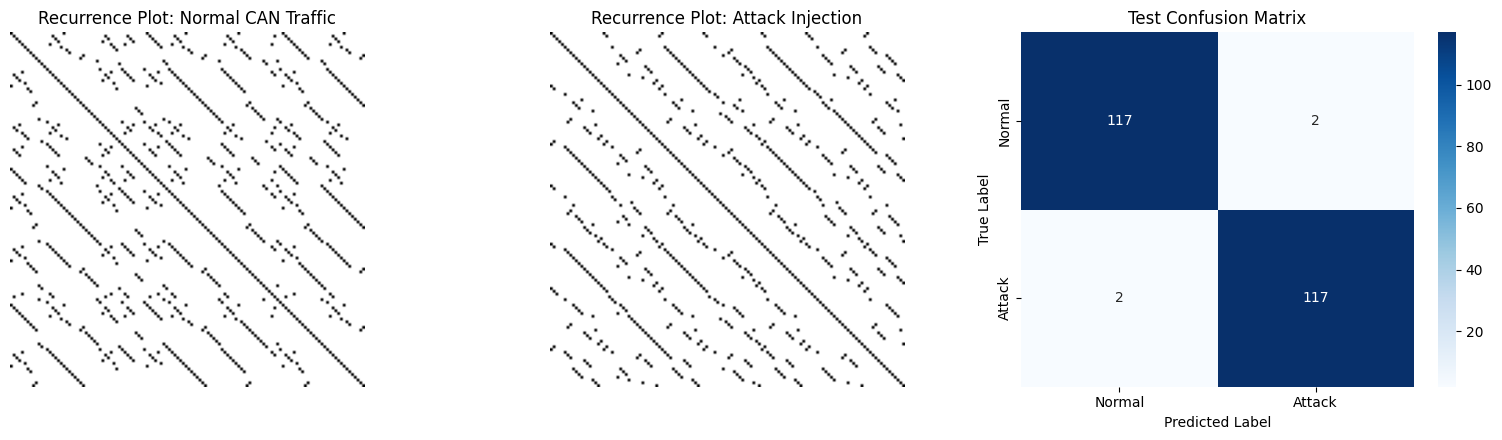


[INFO] Model checkpoint successfully saved to '/content/drive/MyDrive/CAN/lightweight_can_cnn.pth'
[INFO] Model loaded successfully from '/content/drive/MyDrive/CAN/lightweight_can_cnn.pth'

=== EVALUATING NORMAL STREAM ===

[INFO] Processing unseen stream of 128 CAN IDs...
 Window_Index  Prediction_Class Status  Confidence
            0                 0 Normal    0.743955

=== EVALUATING FUZZING ATTACK STREAM ===

[INFO] Processing unseen stream of 128 CAN IDs...
 Window_Index  Prediction_Class          Status  Confidence
            0                 1 Attack Detected    0.692687


In [ ]:
# -*- coding: utf-8 -*-
"""
Lightweight Recurrence Plot CNN for In-Vehicle CAN Intrusion Detection
Thesis Empirical Pipeline: Data Preprocessing, Training, Visualization, & Inference
"""

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight

# Set random seeds for research reproducibility
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using compute device: {device}")


# ==============================================================================
# STEP 1: DIRECT DATA LOADING & BALANCED WINDOW PREPROCESSING
# ==============================================================================
# ==============================================================================
# STEP 1: DIRECT DATA LOADING & OVERLAPPING BALANCED WINDOW PREPROCESSING
# ==============================================================================
def load_and_preprocess_single_csv(file_path, window_size=128, stride=32, max_samples=20000):
    """
    Loads a CAN intrusion CSV file, factorizes CAN IDs into categorical indices,
    and extracts overlapping sliding-window sequences using a custom stride
    to expand dataset volume and prevent 100% training memorization.
    """
    print(f"[INFO] Reading CSV directly from path: {file_path}")

    # Standard Kaggle/HCRL CAN Intrusion Dataset Columns
    df = pd.read_csv(
        file_path,
        names=['Timestamp', 'CAN_ID', 'DLC', 'D0', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'Flag'],
        on_bad_lines='skip',
        low_memory=False
    )

    # Clean string formatting and factorize CAN IDs to dense categorical integers
    df['CAN_ID'] = df['CAN_ID'].astype(str).str.strip()
    df['CAN_ID_Categorical'] = pd.factorize(df['CAN_ID'])[0]

    # Map Flag: 'R' = Normal (0), 'T' or anything else = Attack (1)
    df['Label'] = df['Flag'].apply(lambda x: 0 if str(x).strip().upper() == 'R' else 1)

    can_ids = df['CAN_ID_Categorical'].values
    lbl_vals = df['Label'].values

    normal_seqs, attack_seqs = [], []

    # -------------------------------------------------------------------------
    # ADDED HERE: Extract OVERLAPPING sliding windows using custom stride
    # -------------------------------------------------------------------------
    for i in range(0, len(can_ids) - window_size, stride):
        win_seq = can_ids[i : i + window_size]
        win_lbl = 1 if np.any(lbl_vals[i : i + window_size] == 1) else 0

        if win_lbl == 1:
            attack_seqs.append(win_seq)
        else:
            normal_seqs.append(win_seq)

    # Equal class balancing (50% Normal, 50% Attack)
    min_samples = min(len(normal_seqs), len(attack_seqs), max_samples // 2)

    normal_seqs = normal_seqs[:min_samples]
    attack_seqs = attack_seqs[:min_samples]

    X_raw = np.array(normal_seqs + attack_seqs)
    y_raw = np.array([0] * min_samples + [1] * min_samples)

    # Shuffle dataset maintaining sequence-label alignment
    indices = np.arange(len(X_raw))
    np.random.shuffle(indices)
    X_raw = X_raw[indices]
    y_raw = y_raw[indices]

    print(f"[INFO] Successfully loaded {len(X_raw)} balanced sequences.")
    print(f"[INFO] Class breakdown -> Normal (0): {np.sum(y_raw == 0)}, Attack (1): {np.sum(y_raw == 1)}")

    return X_raw, y_raw


# Pass path to CAN dataset CSV
dataset_path = "/content/drive/MyDrive/CAN/DoS_dataset.csv"

# Extract balanced sequence windows
X_raw, y_raw = load_and_preprocess_single_csv(
    file_path=dataset_path,
    window_size=128,
    max_samples=20000
)


# ==============================================================================
# STEP 2: NATIVE CATEGORICAL RECURRENCE PLOT GENERATION
# ==============================================================================
print("[INFO] Generating Native Categorical Recurrence Plots...")

def generate_categorical_rp(X_sequences):
    """
    Transforms 1D categorical CAN ID sequences into 2D Recurrence Plots
    by evaluating exact frame equality (1 if ID_i == ID_j, else 0).
    """
    N, W = X_sequences.shape
    # Broadcast equality across sequence steps to create (N, W, W) binary matrices
    rp_matrices = (X_sequences[:, :, None] == X_sequences[:, None, :]).astype(np.float32)
    return rp_matrices

# Generate 2D binary recurrence matrices
X_rp = generate_categorical_rp(X_raw)

# Reshape to (N, Channels=1, Height=W, Width=W) for PyTorch 2D Conv Layers
X_rp = np.expand_dims(X_rp, axis=1)

# Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_rp, y_raw, test_size=0.20, random_state=SEED, stratify=y_raw
)


# PyTorch Dataset Wrapper
class CANDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


train_loader = DataLoader(CANDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(CANDataset(X_test, y_test), batch_size=32, shuffle=False)


# ==============================================================================
# STEP 3: LIGHTWEIGHT CNN ARCHITECTURE & TRAINING SETUP
# ==============================================================================
class LightweightCANCNN(nn.Module):
    """
    Lightweight 2D CNN architecture designed for low-parameter
    in-vehicle intrusion detection evaluation.
    """
    def __init__(self, window_size=128):
        super(LightweightCANCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # Shape: (16, W//2, W//2)

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # Shape: (32, W//4, W//4)
        )

        # Dynamic calculation based on input window size
        flattened_size = 32 * (window_size // 4) * (window_size // 4)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = LightweightCANCNN(window_size=128).to(device)

# Compute class weights to maintain balanced penalties
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

# Loss function with label smoothing and regularized Adam optimizer
criterion = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=0.15)
optimizer = optim.Adam(model.parameters(), lr=0.0003, weight_decay=5e-3)


# ==============================================================================
# STEP 4: MODEL TRAINING LOOP (WITH EARLY STOPPING)
# ==============================================================================
print("\n[INFO] Training Lightweight CNN Model...")
best_loss = float('inf')
patience = 2
patience_counter = 0
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_loss = running_loss / len(train_loader)
    train_acc = (correct_train / total_train) * 100

    print(f"  Epoch [{epoch+1:02d}/{epochs:02d}] - Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}%")

    # Early stopping check
    if avg_loss < best_loss:
        best_loss = avg_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"[INFO] Early stopping triggered at Epoch {epoch+1} to avoid overfitting.")
            break


# ==============================================================================
# STEP 5: PERFORMANCE EVALUATION & METRICS
# ==============================================================================
print("\n[INFO] Evaluating model on unseen test set...")
model.eval()
y_pred, y_true = [], []
correct_test = 0
total_test = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total_test += labels.size(0)
        correct_test += (preds == labels).sum().item()

        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

train_accuracy_final = train_acc
test_accuracy_final = (correct_test / total_test) * 100

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
cm = confusion_matrix(y_true, y_pred)

print("\n" + "="*50)
print("        CAN INTRUSION DETECTION PERFORMANCE REPORT")
print("="*50)
print(f" Training Accuracy : {train_accuracy_final:.2f}%")
print(f" Testing Accuracy  : {test_accuracy_final:.2f}%")
print(f" Precision         : {precision:.4f}")
print(f" Recall            : {recall:.4f}")
print(f" F1-Score          : {f1:.4f}")
print("="*50)
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal (0)', 'Attack (1)']))


# ==============================================================================
# STEP 6: VISUALIZATION (Recurrence Plots + Confusion Matrix)
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Plot 1: Recurrence Plot - Normal Frame
axes[0].imshow(X_rp[0, 0], cmap='binary')
axes[0].set_title("Recurrence Plot: Normal CAN Traffic")
axes[0].axis('off')

# Plot 2: Recurrence Plot - Attack Frame
attack_idx = np.where(y_raw == 1)[0][0] if 1 in y_raw else 1
axes[1].imshow(X_rp[attack_idx, 0], cmap='binary')
axes[1].set_title("Recurrence Plot: Attack Injection")
axes[1].axis('off')

# Plot 3: Confusion Matrix
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack']
)
axes[2].set_title("Test Confusion Matrix")
axes[2].set_xlabel("Predicted Label")
axes[2].set_ylabel("True Label")

plt.tight_layout()
plt.show()


# ==============================================================================
# STEP 7: SAVE MODEL WEIGHTS & METADATA
# ==============================================================================
MODEL_SAVE_PATH = "/content/drive/MyDrive/CAN/lightweight_can_cnn.pth"

torch.save({
    'model_state_dict': model.state_dict(),
    'window_size': 128
}, MODEL_SAVE_PATH)

print(f"\n[INFO] Model checkpoint successfully saved to '{MODEL_SAVE_PATH}'")


# ==============================================================================
# STEP 8: INFERENCE PIPELINE ON UNSEEN RAW CAN STREAMS
# ==============================================================================
def load_trained_model(model_path, device):
    """
    Instantiates network architecture and loads trained state dictionary.
    """
    checkpoint = torch.load(model_path, map_location=device)
    window_size = checkpoint.get('window_size', 128)

    loaded_model = LightweightCANCNN(window_size=window_size)
    loaded_model.load_state_dict(checkpoint['model_state_dict'])
    loaded_model.to(device)
    loaded_model.eval()

    print(f"[INFO] Model loaded successfully from '{model_path}'")
    return loaded_model, window_size


loaded_model, WINDOW_SIZE = load_trained_model(MODEL_SAVE_PATH, device)


def predict_raw_can_list(can_id_list, model, device, window_size=128):
    """
    Transforms raw CAN ID streams into 2D Categorical Recurrence Plots
    and generates threat predictions.
    """
    print(f"\n[INFO] Processing unseen stream of {len(can_id_list)} CAN IDs...")

    clean_ids = []
    for item in can_id_list:
        if isinstance(item, str):
            clean_ids.append(int(item, 16) if item.isalnum() else 0)
        else:
            clean_ids.append(int(item))

    can_ids_array = np.array(clean_ids)

    sequences = []
    for i in range(0, len(can_ids_array) - window_size + 1, window_size):
        sequences.append(can_ids_array[i : i + window_size])

    if len(sequences) == 0:
        raise ValueError(
            f"Input stream length ({len(can_id_list)}) is smaller than required window size ({window_size})!"
        )

    X_new_raw = np.array(sequences)

    # Native Categorical Matrix Equality Matching
    X_new_rp = (X_new_raw[:, :, None] == X_new_raw[:, None, :]).astype(np.float32)
    X_new_tensor = torch.tensor(X_new_rp, dtype=torch.float32).unsqueeze(1).to(device)

    with torch.no_grad():
        logits = model(X_new_tensor)
        probabilities = torch.softmax(logits, dim=1)
        confidence_scores, predictions = torch.max(probabilities, dim=1)

    results_df = pd.DataFrame({
        'Window_Index': np.arange(len(predictions)),
        'Prediction_Class': predictions.cpu().numpy(),
        'Status': ['Attack Detected' if p == 1 else 'Normal' for p in predictions.cpu().numpy()],
        'Confidence': confidence_scores.cpu().numpy()
    })

    return results_df


# ==============================================================================
# STEP 9: TEST INFERENCE ON NORMAL & FUZZING INJECTION STREAMS
# ==============================================================================

# Sample 1: Normal Periodic CAN Bus Traffic (128 frames = 1 window of W=128)
unseen_normal_stream = [
    '00C4', '018F', '0280', '0316', '00C4', '018F', '0280', '0316',
    '00C4', '018F', '0280', '0316', '00C4', '018F', '0280', '0316'
] * 8

# Sample 2: High-Entropy Fuzzing Attack Stream (128 random 16-bit hex strings)
unseen_fuzzing_stream = [f"{random.randint(0, 2047):04X}" for _ in range(128)]

print("\n=== EVALUATING NORMAL STREAM ===")
try:
    results_normal = predict_raw_can_list(
        can_id_list=unseen_normal_stream,
        model=loaded_model,
        device=device,
        window_size=WINDOW_SIZE
    )
    print(results_normal.to_string(index=False))
except Exception as e:
    print(f"[ERROR] Could not complete normal stream prediction: {e}")

print("\n=== EVALUATING FUZZING ATTACK STREAM ===")
try:
    results_fuzzing = predict_raw_can_list(
        can_id_list=unseen_fuzzing_stream,
        model=loaded_model,
        device=device,
        window_size=WINDOW_SIZE
    )
    print(results_fuzzing.to_string(index=False))
except Exception as e:
    print(f"[ERROR] Could not complete fuzzing stream prediction: {e}")